# practice two

# mabahese vizhe

# Mohammadali Lotfi kooshali      -        404198471

# 🗂️ Text Classification on 20 Newsgroups Dataset

## 🔍 Overview

We will perform multi-class text classification using the 20 Newsgroups dataset. The goal is to predict the category of a news article based on its text content.


**We will use the following ML models:**
* Logistic Regression
* Multinomial Naive Bayes
* Support Vector Machine (SVM)
* Random Forest
* Extreme Gradient Boosting (XGBoost)
* Decision Tree
* K-Nearest Neighbors (KNN)
* Gradient Boosting Machine (GBM)
* Adaptive Boosting (AdaBoost)
* Extra Trees (Extremely Randomized Trees)
* Light Gradient Boosting Machine (LightGBM)
* Passive Aggressive Classifier

**Key steps include:**
* Loading and exploring the dataset
* Text preprocessing using TF-IDF Vectorization
* Training models and evaluating performance
* Comparing models visually and numerically



## 📊 1. Data Loading and Exploration



In [1]:
from sklearn.datasets import fetch_20newsgroups
import pandas as pd


In [2]:
categories = None

newsgroups_train = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)

newsgroups_test = fetch_20newsgroups(
    subset='test',
    categories=categories,
    remove=('headers', 'footers', 'quotes')
)

df_train = pd.DataFrame({'text': newsgroups_train.data, 'target': newsgroups_train.target})
df_test = pd.DataFrame({'text': newsgroups_test.data, 'target': newsgroups_test.target})

### 🔍 Data Insight and Target Names



In [3]:
df_train['target'].value_counts()

target
10    600
15    599
8     598
9     597
11    595
13    594
7     594
14    593
5     593
2     591
12    591
3     590
6     585
1     584
4     578
17    564
16    546
0     480
18    465
19    377
Name: count, dtype: int64

In [4]:
# List all categories
for idx, category in enumerate(newsgroups_train.target_names):
    print(f"{idx}: {category}")


0: alt.atheism
1: comp.graphics
2: comp.os.ms-windows.misc
3: comp.sys.ibm.pc.hardware
4: comp.sys.mac.hardware
5: comp.windows.x
6: misc.forsale
7: rec.autos
8: rec.motorcycles
9: rec.sport.baseball
10: rec.sport.hockey
11: sci.crypt
12: sci.electronics
13: sci.med
14: sci.space
15: soc.religion.christian
16: talk.politics.guns
17: talk.politics.mideast
18: talk.politics.misc
19: talk.religion.misc


In [5]:
import re
import nltk
nltk.download('stopwords')

from nltk.corpus import stopwords
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'\W+', ' ', text)
    words = [w for w in text.split() if w not in stop_words]
    return ' '.join(words)

df_train['cleaned_text'] = df_train['text'].apply(clean_text)
df_test['cleaned_text'] = df_test['text'].apply(clean_text)

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\ASUS\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## ✨ 2. Preprocessing and TF-IDF Vectorization



In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words='english', max_df=0.7)

X_train = tfidf.fit_transform(df_train['cleaned_text'])
X_test = tfidf.transform(df_test['cleaned_text'])

y_train = df_train['target']
y_test = df_test['target']

print("Shape of TF-IDF matrix:", X_train.shape)

Shape of TF-IDF matrix: (11314, 101295)


## ⚙️ 3. Model Training and Evaluation Functions


In [7]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression, PassiveAggressiveClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from lightgbm import LGBMClassifier

In [8]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": SVC(kernel='linear'),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss'),

    "Decision Tree": DecisionTreeClassifier(),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Extra Trees": ExtraTreesClassifier(n_estimators=100),
    "LightGBM": LGBMClassifier(),
    "Passive Aggressive": PassiveAggressiveClassifier(max_iter=1000)
}


D:\.venv\Lib\site-packages\sklearn\utils\deprecation.py:71: FutureWarning: Class PassiveAggressiveClassifier is deprecated; this is deprecated in version 1.8 and will be removed in 1.10. Use `SGDClassifier(loss='hinge', penalty=None, learning_rate='pa1', eta0=1.0)` instead.
  warnings.warn(msg, category=FutureWarning)


In [9]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test, name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    print(f"\n🔹 {name}")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=newsgroups_train.target_names))

    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6,5))
    sns.heatmap(cm, cmap='Blues', annot=False)
    plt.title(name)
    plt.show()

    return acc

## 🚀 4. Train Models


===== Training Logistic Regression =====

🔹 Logistic Regression
Accuracy: 0.6914
                          precision    recall  f1-score   support

             alt.atheism       0.50      0.46      0.48       319
           comp.graphics       0.63      0.71      0.67       389
 comp.os.ms-windows.misc       0.65      0.62      0.64       394
comp.sys.ibm.pc.hardware       0.68      0.64      0.66       392
   comp.sys.mac.hardware       0.75      0.69      0.72       385
          comp.windows.x       0.84      0.73      0.78       395
            misc.forsale       0.75      0.79      0.77       390
               rec.autos       0.76      0.71      0.73       396
         rec.motorcycles       0.48      0.81      0.60       398
      rec.sport.baseball       0.82      0.82      0.82       397
        rec.sport.hockey       0.91      0.87      0.89       399
               sci.crypt       0.90      0.66      0.76       396
         sci.electronics       0.56      0.61      0.58    

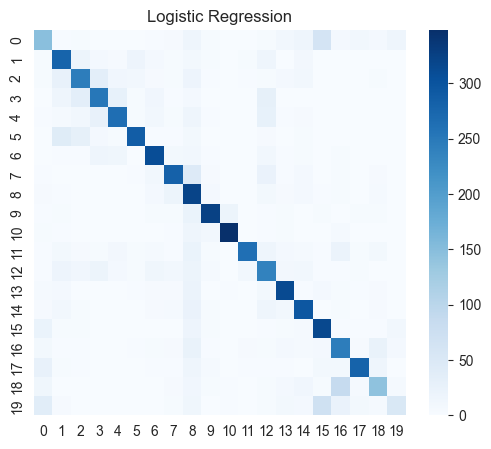


===== Training Naive Bayes =====

🔹 Naive Bayes
Accuracy: 0.6799
                          precision    recall  f1-score   support

             alt.atheism       0.78      0.18      0.30       319
           comp.graphics       0.67      0.69      0.68       389
 comp.os.ms-windows.misc       0.66      0.59      0.62       394
comp.sys.ibm.pc.hardware       0.60      0.74      0.66       392
   comp.sys.mac.hardware       0.77      0.67      0.72       385
          comp.windows.x       0.81      0.77      0.79       395
            misc.forsale       0.77      0.77      0.77       390
               rec.autos       0.83      0.73      0.78       396
         rec.motorcycles       0.87      0.74      0.80       398
      rec.sport.baseball       0.93      0.80      0.86       397
        rec.sport.hockey       0.57      0.93      0.71       399
               sci.crypt       0.59      0.79      0.68       396
         sci.electronics       0.71      0.52      0.60       393
         

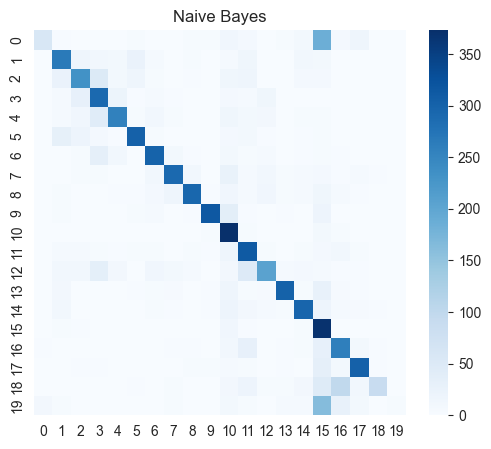


===== Training SVM =====

🔹 SVM
Accuracy: 0.6747
                          precision    recall  f1-score   support

             alt.atheism       0.48      0.47      0.47       319
           comp.graphics       0.60      0.71      0.65       389
 comp.os.ms-windows.misc       0.65      0.61      0.63       394
comp.sys.ibm.pc.hardware       0.65      0.66      0.66       392
   comp.sys.mac.hardware       0.73      0.65      0.69       385
          comp.windows.x       0.86      0.66      0.75       395
            misc.forsale       0.77      0.78      0.77       390
               rec.autos       0.65      0.73      0.68       396
         rec.motorcycles       0.45      0.79      0.58       398
      rec.sport.baseball       0.81      0.78      0.79       397
        rec.sport.hockey       0.92      0.82      0.87       399
               sci.crypt       0.89      0.68      0.77       396
         sci.electronics       0.56      0.61      0.58       393
                 sci.med 

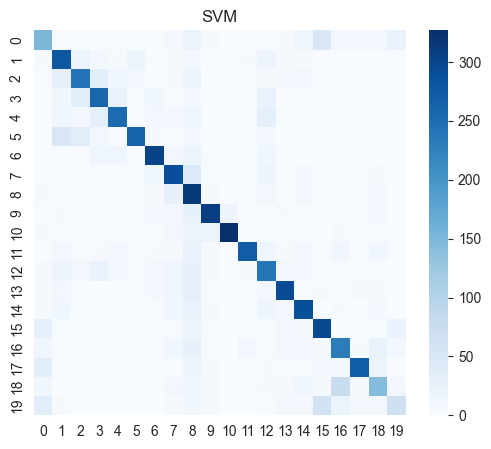


===== Training Random Forest =====

🔹 Random Forest
Accuracy: 0.6247
                          precision    recall  f1-score   support

             alt.atheism       0.42      0.39      0.40       319
           comp.graphics       0.57      0.60      0.58       389
 comp.os.ms-windows.misc       0.55      0.64      0.59       394
comp.sys.ibm.pc.hardware       0.60      0.57      0.58       392
   comp.sys.mac.hardware       0.68      0.65      0.66       385
          comp.windows.x       0.64      0.70      0.67       395
            misc.forsale       0.72      0.75      0.74       390
               rec.autos       0.41      0.69      0.51       396
         rec.motorcycles       0.72      0.67      0.70       398
      rec.sport.baseball       0.71      0.79      0.75       397
        rec.sport.hockey       0.82      0.82      0.82       399
               sci.crypt       0.79      0.67      0.72       396
         sci.electronics       0.51      0.42      0.46       393
     

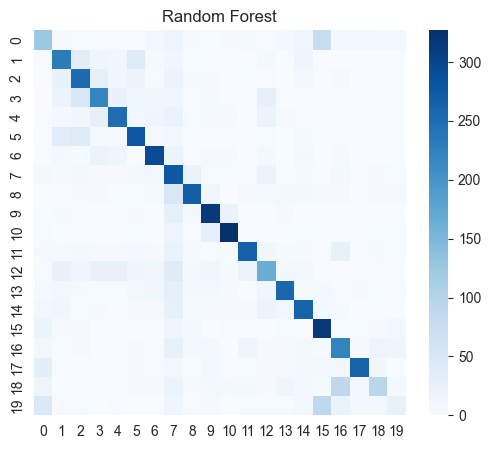


===== Training XGBoost =====


D:\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:40:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔹 XGBoost
Accuracy: 0.6085
                          precision    recall  f1-score   support

             alt.atheism       0.42      0.36      0.39       319
           comp.graphics       0.57      0.62      0.59       389
 comp.os.ms-windows.misc       0.57      0.58      0.57       394
comp.sys.ibm.pc.hardware       0.60      0.60      0.60       392
   comp.sys.mac.hardware       0.63      0.67      0.65       385
          comp.windows.x       0.74      0.66      0.70       395
            misc.forsale       0.72      0.71      0.72       390
               rec.autos       0.63      0.62      0.62       396
         rec.motorcycles       0.42      0.74      0.53       398
      rec.sport.baseball       0.72      0.70      0.71       397
        rec.sport.hockey       0.83      0.79      0.81       399
               sci.crypt       0.75      0.64      0.69       396
         sci.electronics       0.46      0.45      0.46       393
                 sci.med       0.70      0.63  

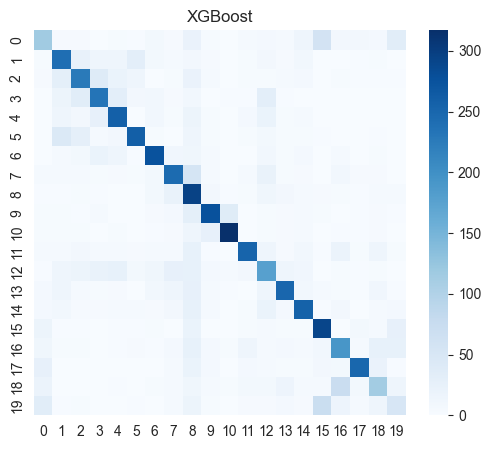


===== Training Decision Tree =====

🔹 Decision Tree
Accuracy: 0.4426
                          precision    recall  f1-score   support

             alt.atheism       0.26      0.26      0.26       319
           comp.graphics       0.46      0.42      0.44       389
 comp.os.ms-windows.misc       0.44      0.45      0.44       394
comp.sys.ibm.pc.hardware       0.41      0.41      0.41       392
   comp.sys.mac.hardware       0.41      0.43      0.42       385
          comp.windows.x       0.50      0.48      0.49       395
            misc.forsale       0.55      0.56      0.55       390
               rec.autos       0.26      0.55      0.36       396
         rec.motorcycles       0.56      0.54      0.55       398
      rec.sport.baseball       0.57      0.49      0.53       397
        rec.sport.hockey       0.65      0.61      0.63       399
               sci.crypt       0.57      0.47      0.52       396
         sci.electronics       0.30      0.31      0.30       393
     

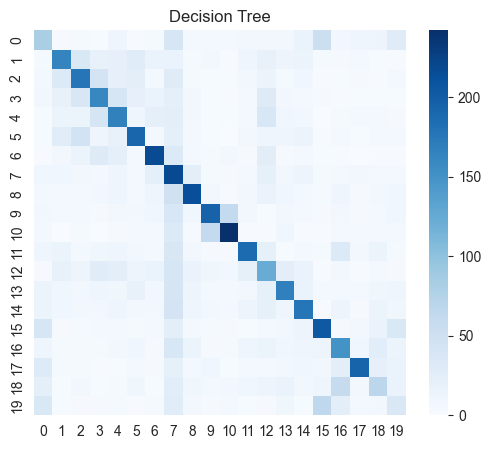


===== Training KNN =====

🔹 KNN
Accuracy: 0.0773
                          precision    recall  f1-score   support

             alt.atheism       0.05      0.17      0.08       319
           comp.graphics       0.06      0.14      0.09       389
 comp.os.ms-windows.misc       0.06      0.23      0.09       394
comp.sys.ibm.pc.hardware       0.11      0.16      0.13       392
   comp.sys.mac.hardware       0.07      0.15      0.10       385
          comp.windows.x       0.13      0.02      0.03       395
            misc.forsale       0.22      0.08      0.12       390
               rec.autos       0.05      0.10      0.07       396
         rec.motorcycles       0.12      0.05      0.07       398
      rec.sport.baseball       0.07      0.05      0.05       397
        rec.sport.hockey       0.14      0.05      0.08       399
               sci.crypt       0.14      0.03      0.04       396
         sci.electronics       0.10      0.04      0.06       393
                 sci.med 

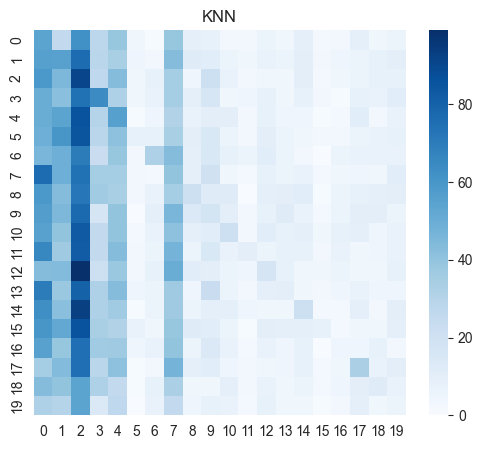


===== Training Gradient Boosting =====

🔹 Gradient Boosting
Accuracy: 0.5972
                          precision    recall  f1-score   support

             alt.atheism       0.53      0.39      0.45       319
           comp.graphics       0.57      0.62      0.60       389
 comp.os.ms-windows.misc       0.63      0.57      0.59       394
comp.sys.ibm.pc.hardware       0.56      0.64      0.59       392
   comp.sys.mac.hardware       0.72      0.63      0.67       385
          comp.windows.x       0.82      0.60      0.69       395
            misc.forsale       0.70      0.66      0.68       390
               rec.autos       0.75      0.60      0.66       396
         rec.motorcycles       0.78      0.62      0.69       398
      rec.sport.baseball       0.82      0.65      0.73       397
        rec.sport.hockey       0.80      0.78      0.79       399
               sci.crypt       0.79      0.60      0.68       396
         sci.electronics       0.18      0.61      0.28       3

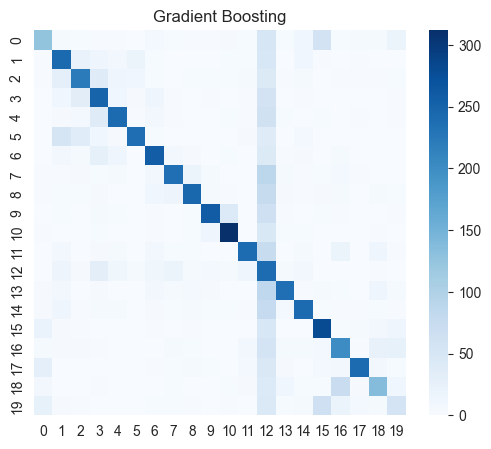


===== Training AdaBoost =====

🔹 AdaBoost
Accuracy: 0.2669
                          precision    recall  f1-score   support

             alt.atheism       0.00      0.00      0.00       319
           comp.graphics       0.70      0.23      0.34       389
 comp.os.ms-windows.misc       0.56      0.49      0.52       394
comp.sys.ibm.pc.hardware       0.06      0.83      0.12       392
   comp.sys.mac.hardware       0.66      0.36      0.46       385
          comp.windows.x       0.79      0.27      0.40       395
            misc.forsale       0.74      0.32      0.45       390
               rec.autos       0.74      0.39      0.51       396
         rec.motorcycles       0.93      0.24      0.39       398
      rec.sport.baseball       0.00      0.00      0.00       397
        rec.sport.hockey       0.68      0.40      0.50       399
               sci.crypt       0.94      0.31      0.47       396
         sci.electronics       0.00      0.00      0.00       393
               

D:\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
D:\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


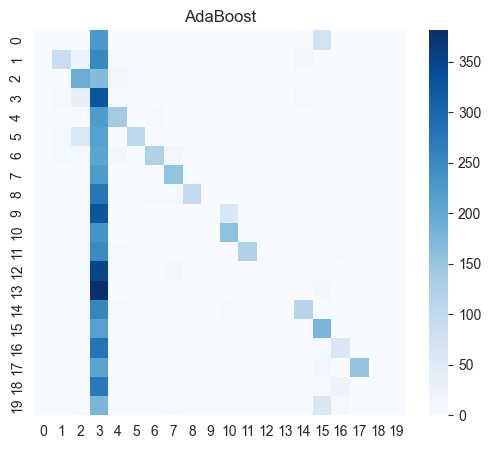


===== Training Extra Trees =====

🔹 Extra Trees
Accuracy: 0.6510
                          precision    recall  f1-score   support

             alt.atheism       0.46      0.41      0.43       319
           comp.graphics       0.59      0.67      0.63       389
 comp.os.ms-windows.misc       0.58      0.65      0.61       394
comp.sys.ibm.pc.hardware       0.62      0.61      0.61       392
   comp.sys.mac.hardware       0.65      0.66      0.66       385
          comp.windows.x       0.72      0.71      0.71       395
            misc.forsale       0.74      0.75      0.75       390
               rec.autos       0.44      0.73      0.55       396
         rec.motorcycles       0.70      0.70      0.70       398
      rec.sport.baseball       0.73      0.80      0.76       397
        rec.sport.hockey       0.85      0.84      0.84       399
               sci.crypt       0.80      0.70      0.74       396
         sci.electronics       0.55      0.48      0.51       393
         

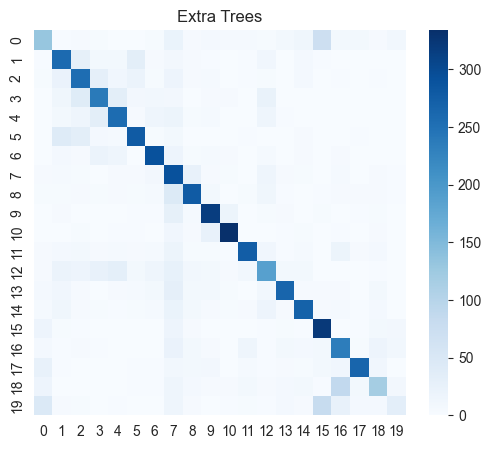


===== Training LightGBM =====
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.055052 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 174338
[LightGBM] [Info] Number of data points in the train set: 11314, number of used features: 5995
[LightGBM] [Info] Start training from score -3.160010
[LightGBM] [Info] Start training from score -2.963895
[LightGBM] [Info] Start training from score -2.951980
[LightGBM] [Info] Start training from score -2.953674
[LightGBM] [Info] Start training from score -2.974222
[LightGBM] [Info] Start training from score -2.948602
[LightGBM] [Info] Start training from score -2.962184
[LightGBM] [Info] Start training from score -2.946917
[LightGBM] [Info] Start training from score -2.940205
[LightGBM] [Info] Start training from score -2.941879
[LightGBM] [Info] Start training from score -2.936867
[LightGBM] [Info] 

D:\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



🔹 LightGBM
Accuracy: 0.6115
                          precision    recall  f1-score   support

             alt.atheism       0.39      0.40      0.39       319
           comp.graphics       0.54      0.62      0.58       389
 comp.os.ms-windows.misc       0.57      0.60      0.58       394
comp.sys.ibm.pc.hardware       0.58      0.57      0.57       392
   comp.sys.mac.hardware       0.66      0.65      0.66       385
          comp.windows.x       0.73      0.64      0.68       395
            misc.forsale       0.75      0.71      0.73       390
               rec.autos       0.41      0.70      0.52       396
         rec.motorcycles       0.66      0.67      0.67       398
      rec.sport.baseball       0.76      0.70      0.73       397
        rec.sport.hockey       0.83      0.80      0.82       399
               sci.crypt       0.79      0.63      0.70       396
         sci.electronics       0.50      0.51      0.50       393
                 sci.med       0.68      0.64 

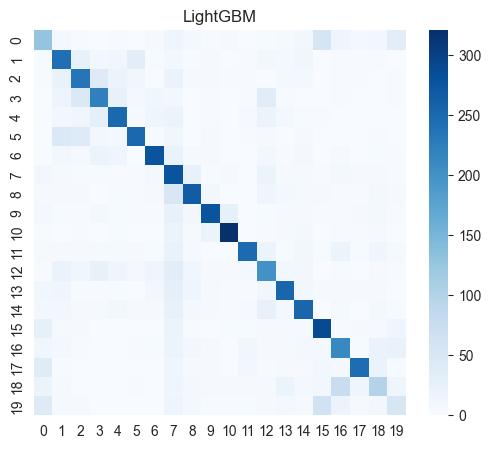


===== Training Passive Aggressive =====

🔹 Passive Aggressive
Accuracy: 0.6768
                          precision    recall  f1-score   support

             alt.atheism       0.51      0.49      0.50       319
           comp.graphics       0.65      0.70      0.67       389
 comp.os.ms-windows.misc       0.62      0.58      0.60       394
comp.sys.ibm.pc.hardware       0.58      0.64      0.61       392
   comp.sys.mac.hardware       0.69      0.66      0.68       385
          comp.windows.x       0.77      0.69      0.73       395
            misc.forsale       0.73      0.75      0.74       390
               rec.autos       0.74      0.70      0.72       396
         rec.motorcycles       0.49      0.76      0.59       398
      rec.sport.baseball       0.87      0.80      0.83       397
        rec.sport.hockey       0.86      0.86      0.86       399
               sci.crypt       0.85      0.70      0.77       396
         sci.electronics       0.65      0.57      0.61      

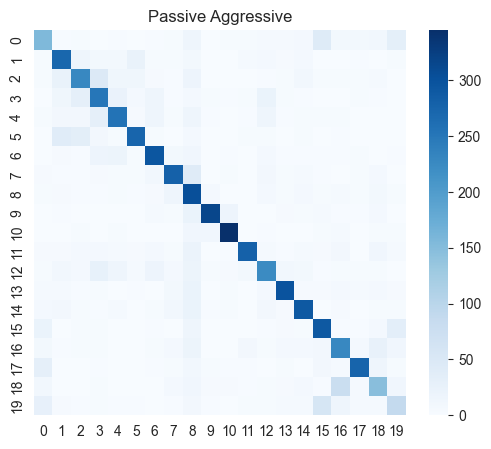

In [10]:
accuracies = {}

for name, model in models.items():
    print(f"\n===== Training {name} =====")
    model.fit(X_train, y_train)
    acc = evaluate_model(model, X_test, y_test, name)
    accuracies[name] = acc

## 📈 5. Performance Comparison

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7992\1508749860.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='viridis')


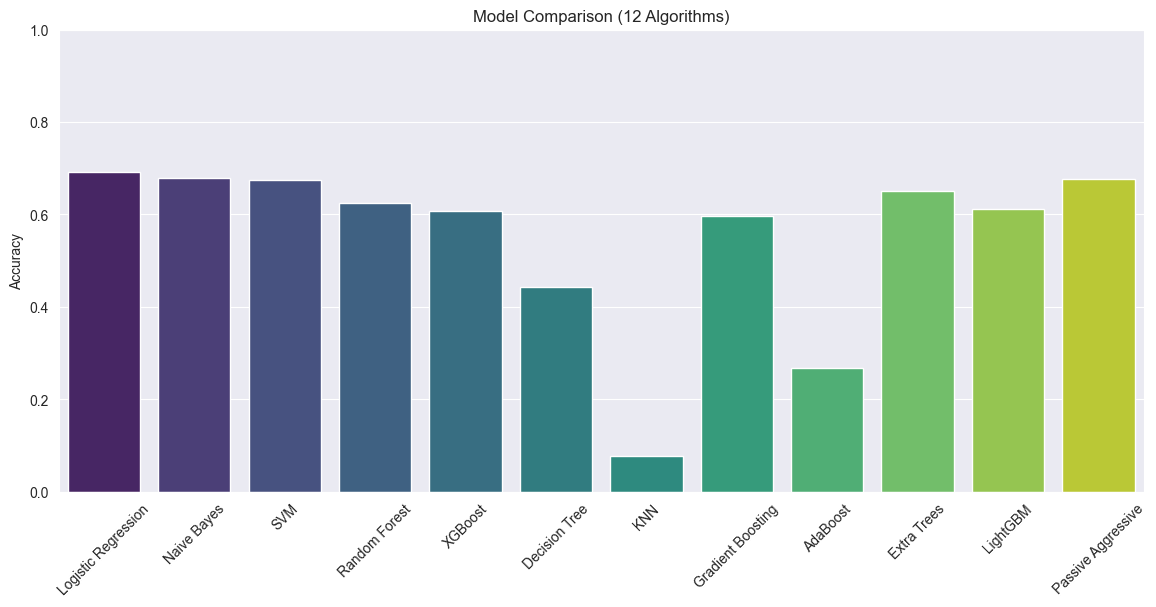

In [11]:
plt.figure(figsize=(14,6))
sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='viridis')

plt.xticks(rotation=45)
plt.title("Model Comparison (12 Algorithms)")
plt.ylabel("Accuracy")
plt.ylim(0,1)

plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_7992\2471165340.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='viridis')


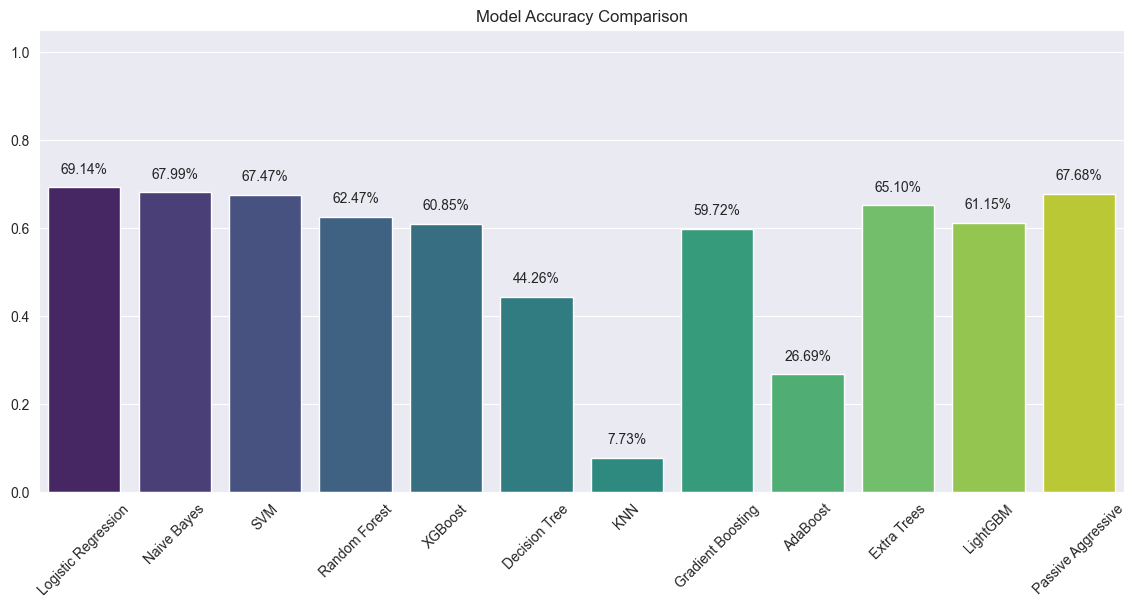

In [12]:
plt.figure(figsize=(14,6))
ax = sns.barplot(x=list(accuracies.keys()), y=list(accuracies.values()), palette='viridis')

for p in ax.patches:
    ax.annotate(f"{p.get_height():.2%}",
                (p.get_x() + p.get_width()/2., p.get_height()),
                ha='center', va='bottom',
                xytext=(0,8), textcoords='offset points')

plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.ylim(0,1.05)
plt.show()